# Visualization Part 2: Starter Notebook

This notebook is a guided template for the individual visualization assignment.

You are expected to do more than make plots. You must explain whether your plot choices are clear, appropriate, honest, and interpretable.

Complete every section in order. Do not delete the prompts.


## What this notebook is testing

In this notebook, you must demonstrate that you can:

- choose a reasonable plot for a question
- use grouping or conditioning when needed
- think about scale carefully
- apply a transformation when it improves interpretation
- identify when a plot is misleading
- revise a weak plot into a stronger one
- explain what a plot shows in full sentences

A plot is not automatically good just because code produced it.


## Setup

Load the toy dataset first. Then inspect its structure before plotting anything.


In [187]:
# TODO: Import the libraries you need.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the toy dataset.
df = pd.read_csv("ethereum_messages_toy.csv")

# TODO: Display the first 5 rows.
df.head()


,message_type,sender_address,receiver_address,amount,transaction_flag,message_length
0,normal,0xaed548b0ad2ad42d36a65fc9fbb7365290273735,0xadebdbe4ffde843c5c0942476dafed98f4081ed2,12.7777,1,115
1,begging,0x380d92bab460b09297a542e4b0198e2c87e43c62,0x62afa887ea89b1b66c12e70d25de9412bdf3ddb4,1.5590,1,97
2,scam,0x87bd4dc83166db001549b0f7dd10ed8172a97987,0xc1d0a09e6109925ce9325a327c9bc34db8d33032,97.4377,1,210
3,normal,0xd5d04ef6b199bde888fc75394a7e49cbb2e35d4e,0x187b0ea64e520ab88273cce8678ddb6803c87968,6.0098,1,104
4,scam,0x5f8676e6b77d71e6dadf79e40929b9c9eb05f320,0x3e5a82554fb4ff75ee00ec09483e2ae03411d186,25.5839,1,103


## Initial inspection

Answer the following with code and short written notes:

1. How many rows and columns are in the dataset?
2. What are the data types?
3. Which columns are categorical?
4. Which columns are numerical?
5. Are there any columns that may need cleaning or special handling before plotting?


In [188]:
# TODO: Inspect the dataset using shape, info, describe, and any other helpful commands.

# Shape
print("Num Rows, Num Columns:", df.shape)

# Data Types
print("\nData types:")
print(df.dtypes)


# Categorical Columns
categorical_cols = df.select_dtypes(include='object').columns
print("\nCategorical columns:")
print(categorical_cols)

# Numerical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical columns:")
print(numerical_cols)

# Columns requiring cleaning of special handling prior to plotting

print("\nTransaction flag is categorical data although it has a numerical datatype."
      "\nSender/Receiver addresses are unique identifiers."
      "\nAmount may require a logarithmic function due to its skew.")

Num Rows, Num Columns: (1500, 6)

Data types:
message_type         object
sender_address       object
receiver_address     object
amount              float64
transaction_flag      int64
message_length        int64
dtype: object

Categorical columns:
Index(['message_type', 'sender_address', 'receiver_address'], dtype='object')

Numerical columns:
Index(['amount', 'transaction_flag', 'message_length'], dtype='object')

Transaction flag is categorical data although it has a numerical datatype.
Sender/Receiver addresses are unique identifiers.
Amount may require a logarithmic function due to its skew.


There are 1500 Rows and 6 Columns in this dataset. Columns that may need special handling include amount which may require a logarithmic transformation due to its skew. The sender/receiver are identifiers, so visualization might be tough with them since there are many unique ones. Another note is that the transaction flag variable is categorical data although it is presented in numerical form.


# Part A: Toy Dataset Visualization Practice

For Part A, everyone is working with the same toy dataset.

Each row represents one message or transaction.

Columns include:
- `message_type`
- `sender_address`
- `receiver_address`
- `amount`
- `transaction_flag`
- `message_length`

You must complete all required plots in this section.

Important requirements for Part A:
- You must discuss scale.
- You must discuss transformation.
- You must discuss grouping or conditioning where relevant.
- At least one plot must be shown in both an original version and a transformed version.


## Part A, Plot 1: Category count plot

Create a plot that answers this question:

**How many messages belong to each message type?**

After the plot, write 4 to 6 full sentences answering:
1. What question are you answering?
2. Why is a count plot or bar chart appropriate here?
3. What does the plot show?
4. Is there anything about scale, ordering, or labeling that could make this easier to read?
5. What is one limitation of this plot?


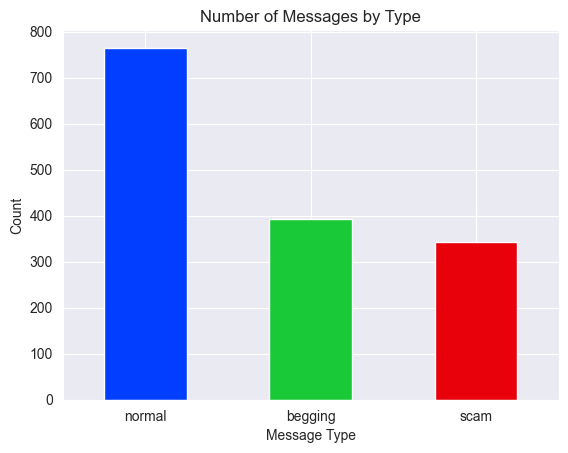

In [189]:
# TODO: Create a category count plot for message_type.
colors = sns.color_palette("bright6")

df["message_type"].value_counts().sort_values(ascending=False).plot(kind="bar", color=colors)
plt.title("Number of Messages by Type")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()


The question that we are answering is which category of messages has the greatest number of messages associated with it. A bar chart is appropriate as it is a simple and effective way to display numerical data and counts across variables. The plot shows the count of messages by message type. I believe that this bar chart is at its easiest-to-read form and it would be difficult to make it much better, as it is rather straightforward. A limitation of this plot might be that it is difficult to tell the exact count of each category, and you can only see an approximation rather than an exact value.

## Part A, Plot 2: Group comparison with conditioning

Create a plot that answers this question:

**How does the average transaction amount differ across message types?**

Requirements:
- You must group or aggregate the data first.
- You must make it obvious that you are comparing groups.

After the plot, write 4 to 6 full sentences answering:
1. What is being compared?
2. What grouping or aggregation did you use?
3. Why is this plot type reasonable?
4. Which group appears highest or lowest?
5. What important detail might be hidden by averaging?


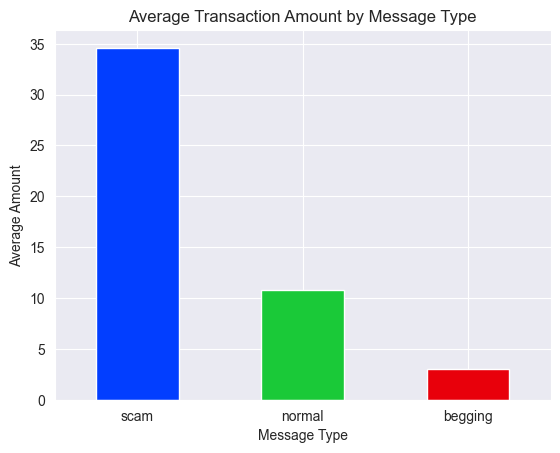

In [190]:
# TODO: Group the data by message_type and compare average amount.

colors = sns.color_palette("bright6")

avg_amt = df.groupby("message_type")["amount"].mean()
avg_amt.sort_values(ascending=False).plot(kind="bar", color=colors)
plt.title("Average Transaction Amount by Message Type")
plt.xlabel("Message Type")
plt.ylabel("Average Amount")
plt.xticks(rotation=0)

plt.show()


The average transaction amount is being compared by the type of message sent. I grouped the data by message type and then took the mean transaction amount for each category. This plot type is reasonable due to the fact that a bar chart is a simple method to display the differences in value count per message type and immediately see which message type has the greatest average transaction amount. The "scam" message type has the highest average transaction amount by a large margin, and the "begging" message type has the lowest transaction amount. An important detail that may be hid by averaging is the information of data shape and skew and which category extremely high outlying data may fall into, as well as whether outlying data is impacting the mean value by causing it to drastically either decrease or increase.

## Part A, Plot 3: Distribution and transformation

Create a histogram that answers this question:

**What does the distribution of transaction amount look like?**

Then create a second version of the plot using a transformation, such as a log transformation.

Requirements:
- Show the original distribution.
- Show the transformed distribution.
- Compare them.

After the plots, write 4 to 6 full sentences answering:
1. What does the original distribution look like?
2. Is it skewed?
3. Why might a transformation help?
4. How does the transformed version change what you can see?
5. Which version is easier to interpret, and why?


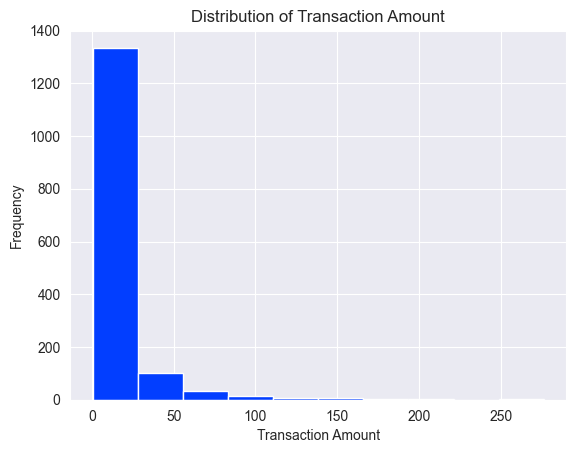

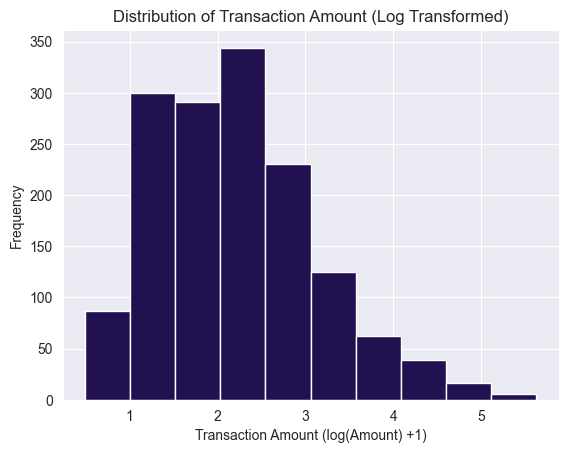

In [191]:
# TODO: Create the original histogram for amount.

colors = sns.color_palette("bright")

transactions = df["amount"]
transactions.plot(kind="hist", color=colors)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.xticks(rotation=0)

plt.show()

# TODO: Create a transformed version, such as log(amount + 1), and plot it.

colors = sns.color_palette("magma")

transactions_log = np.log1p(df["amount"])
transactions_log.plot(kind="hist", color=colors)
plt.title("Distribution of Transaction Amount (Log Transformed)")
plt.xlabel("Transaction Amount (log(Amount) +1)")
plt.ylabel("Frequency")
plt.xticks(rotation=0)

plt.show()

The original distribution looks fairly skewed to the right and seems to be unimodal and fairly concentrated on the left between the 0-25 points. A transformation may allow us to recognize the underlying patterns within the dats by honing in on it and reducing the potency of the outliers within the data causing the major skew as displayed in the pre-transformation histogram to reduce due to the logarithmic transformation reducing large values and therefore enhancing diversity between smaller values. The version that I believe is easier to interpret is the log-transformed version, since it is easier for us to see the variability and trends between the majority of the transaction amount values more clearly.

## Part A, Plot 4: Relationship plot with scale consideration

Create a plot that answers this question:

**What is the relationship between message length and transaction amount?**

Requirements:
- Use a plot type that can show the relationship between two numerical variables.
- Think carefully about whether the raw scale makes the pattern hard to see.
- Consider whether a transformation would make the relationship clearer.

After the plot, write 4 to 6 full sentences answering:
1. Why did you choose this plot type?
2. Is there an obvious pattern, trend, or cluster?
3. Does scale make the plot hard to read?
4. Would transforming one of the variables help?
5. What is one limitation of this relationship plot?


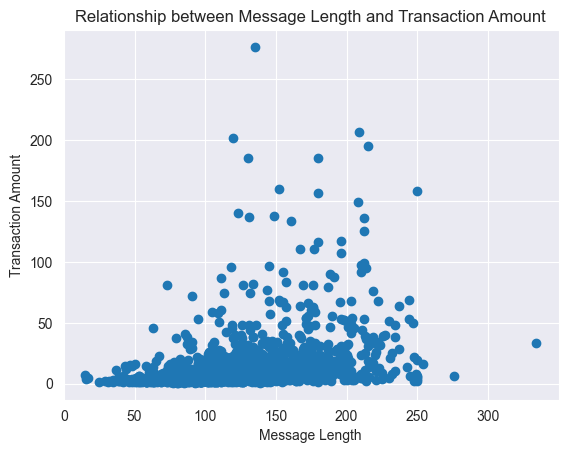

In [192]:
# TODO: Create a relationship plot between message_length and amount.
# TODO: If helpful, create a second version with a transformed scale.

colors = sns.color_palette("magma")

plt.scatter(df["message_length"], df["amount"])
plt.title("Relationship between Message Length and Transaction Amount")
plt.xlabel("Message Length")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=0)

plt.show()

I chose the scatter plot type as it allows to express the trends of the data, if an obvious one exists without ignoring the outlying values. There seems to be no outstanding trend between the variables, but the higher transactions seem to follow a general trend of being around the 100-200 message length mark. The lower transaction values seem to follow an level trend throughout the varying message lengths. The scale somewhat reduces the readability of the plot due to the fact that the majority of the data is concentrated in the 0-50 mark of transaction amounts. Transforming the transaction amount variable to be shown through a logarithmic scale would help the variation between the smaller numbers to be more clear while reducing the potency of the outliers within the data. A limitation of this relationship plot is that it displays a trend that may not be due to causation, but rather correlates due to the effect of other variables.

## Part A, Plot 5: Intentionally misleading plot

You must intentionally create a misleading plot.

Choose one of the following ways to mislead the viewer:
- truncate the y-axis
- use an inappropriate scale
- choose a poor plot type
- hide important variation through aggregation

Then create a corrected version of the same plot.

After both plots, write 5 to 7 full sentences answering:
1. What did you do to make the first plot misleading?
2. Why could a viewer draw the wrong conclusion from it?
3. What is different in the corrected plot?
4. How does the corrected version improve honesty and clarity?
5. What does this teach you about visualization ethics?


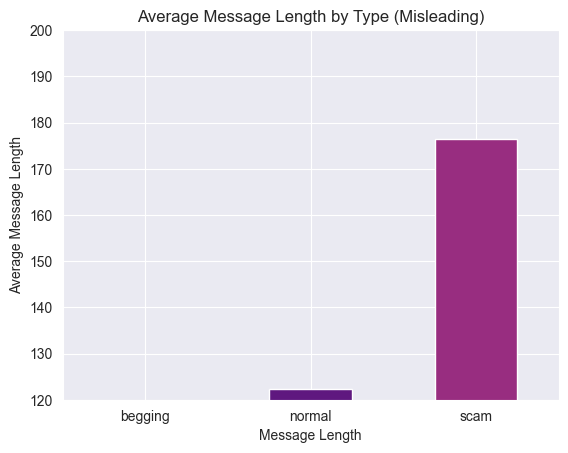

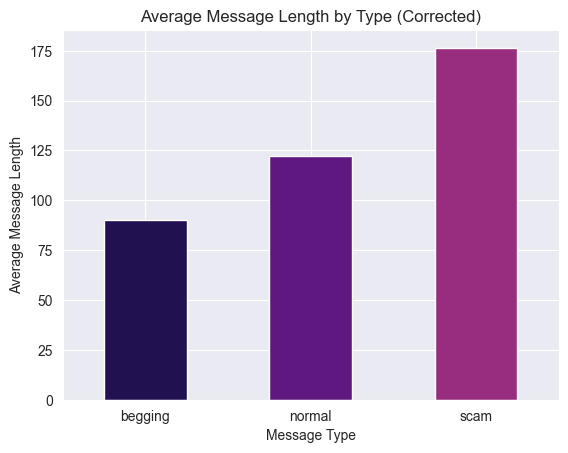

In [193]:
# TODO: Create an intentionally misleading plot.
colors = sns.color_palette("magma")

# group by type, mean of each length
avg_message_length = df.groupby("message_type")["message_length"].mean().sort_values()

# Misleading plot
avg_message_length.plot(kind="bar", color=colors)
# Intentionally misleading truncation of y-axis.
plt.ylim(120,200)
plt.title("Average Message Length by Type (Misleading)")
plt.xlabel("Message Length")
plt.ylabel("Average Message Length")
plt.xticks(rotation=0)
plt.show()

# TODO: Create a corrected version of the same plot.
avg_message_length.plot(kind="bar", color=colors)
plt.title("Average Message Length by Type (Corrected)")
plt.xlabel("Message Type")
plt.ylabel("Average Message Length")
plt.xticks(rotation=0)
plt.show()


I made the first plot misleading through y-axis truncation. I made it misleading since although the scam category of the message types variable does have a significantly higher average message length than the other categories, truncating the y-axis of the graph made the difference look largely more drastic. A viewer could draw very inaccurate conclusions unless they closely look at the graph's y-axis, as this truncation makes it seem as though there is no begging message data, and normal message types tend to have a disproportionately smaller average message length than scam message types. In the corrected plot, the complete y-axis is displayed, and therefore, the proportions are cleared up between the bars, and the datatypes do not look much smaller than others, but rather sensibly display the average message length across different message types. It is much more clear and honest from the second visualization that there is a reasonable difference in length across the message types, and not a widely drastic and extremely notable difference as displayed in the first graph in which the normal message type's average length was seemingly only around 1/15th of the scam message type's. This teaches me that it is very easy to manipulate a graph to display data to back any agenda, and therefore it is definitely ethically in everyone's best interest to double-check that visualizations are always presented in a comprehensive and easily-digestible manner.

# Part B: Redo Two Visualizations from Phase 2

Return to your own project dataset.

Select **two** plots from your Phase 2 work and redo them.

You may not simply paste the same plot again. You must improve them.

Possible improvements include:
- better scale
- transformation
- clearer grouping
- better ordering of categories
- better labels
- better titles
- better readability
- a more appropriate plot type

For each revised plot, include:
- the original Phase 2 question
- the revised plot
- a short paragraph explaining what was weak in the original version
- a short paragraph explaining what you changed and why it is better


In [194]:
# Loading and re-cleaning the project dataset
df1 = pd.read_csv('world_bank_data_2025.csv')
df2 = pd.read_csv('GDI_2000_2020.csv')

# Clean:

# Outer merge maintains both datasets' data,
# while joining on country and year allows for clean representation of data.
df_merged = pd.merge(df1, df2, how='outer',
                     left_on=['country_name', 'year'],
                     right_on=['country_name', 'year'])

# Combine equivalent columns
df_merged['Unemployment Rate (%)'] = df_merged['Unemployment Rate (%)'] \
    .combine_first(df_merged['unemployment_rate'])

df_merged['Inflation (GDP Deflator, %)'] = df_merged['Inflation (GDP Deflator, %)'] \
    .combine_first(df_merged['inflation_rate'])

df_merged['country_id'] = df_merged['country_id'] \
    .combine_first(df_merged['country_code'])

df_merged['GDP (Current USD)'] = df_merged['GDP (Current USD)'] \
    .combine_first(df_merged['gdp_usd'])

df_merged['GDP per Capita (Current USD)'] = df_merged['GDP per Capita (Current USD)'] \
    .combine_first(df_merged['gdp_per_capita'])

# Drop the duplicate columns
df_merged = df_merged.drop(columns=[
    'unemployment_rate',
    'inflation_rate',
    'country_code',
    'gdp_usd',
    'gdp_per_capita'
])

# Only keep relevant columns and data
df_merged_clean = df_merged[[
      'country_name',
      'country_id',
      'year',
      'Inflation (GDP Deflator, %)',
      'GDP (Current USD)',
      'Unemployment Rate (%)'
    ]]

df_merged_clean = df_merged_clean.rename(columns={
    'Inflation (GDP Deflator, %)': 'inflation',
    'GDP (Current USD)': 'gdp_usd',
    'Unemployment Rate (%)': 'unemployment_rate',
})

# Add a column for GDP group (categorical data) using pd.qcut.
# Splits into three equal sized groups with lower third, middle, and highest third.
df_merged_clean['gdp_group'] = pd.qcut(
    df_merged_clean['gdp_usd'],
    3,
    labels=['Low GDP', 'Medium GDP', 'High GDP']
)

# Add a column categorizing inflation.
# Categorize inflation into groups based on whether deflation/low/mod/high.
df_merged_clean['inflation_category'] = pd.cut(
    df_merged_clean['inflation'],
    bins=[-float('inf'), 0, 5, 10, float('inf')],
    labels=['Deflation', 'Low', 'Moderate', 'High']
)

# Clean out any NANs so they don't show on graph.
df_inflation_clean= df_merged_clean.dropna(subset=['inflation_category'])

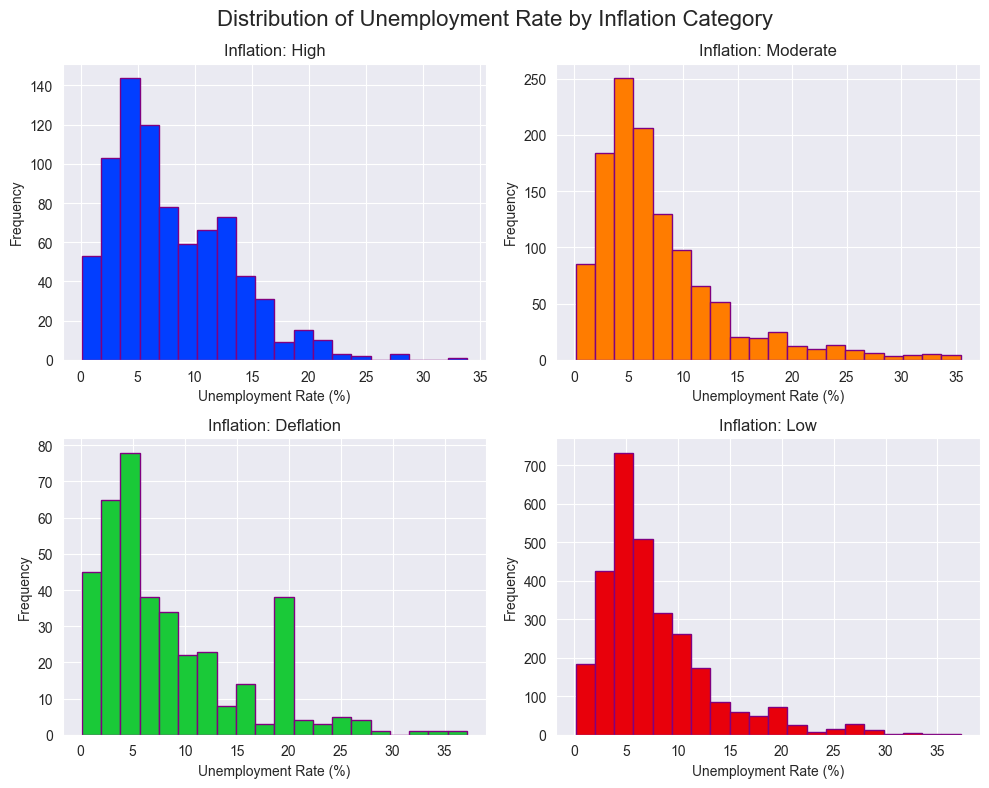

In [195]:
# Redo of plot #1

# Plot histogram of unemployment rate for each category
# Instead of overlapping histograms like in initial graph,
# separating into three adjacent histograms for clarity.

categories = df_inflation_clean['inflation_category'].unique()
colors = sns.color_palette("bright")

plt.figure(figsize=(10, 8))
plt.suptitle('Distribution of Unemployment Rate by Inflation Category', fontsize=16)

for i, (category, color) in enumerate(zip(categories, colors)):
    plt.subplot(2, 2, i+1)
    subset = df_inflation_clean[df_inflation_clean["inflation_category"] == category]
    plt.hist(subset["unemployment_rate"], bins=20, color=color, edgecolor='purple')
    plt.title(f"Inflation: {category}")
    plt.xlabel("Unemployment Rate (%)")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Rather than overlapping the histograms as I did prior in my original plot, which was weak as it was visually unclear and could cause visual misunderstanding, I created 4 separate adjacent histograms by category so that the distributions could be easily compared side by side. In my previous plot, the overlapping histograms were confusing and pretty hard to read for a lot of people. With this improved version, all four categories of inflation are easily comparable by their unemployment rate distributions, and it is clear how inflation and unemployment rate correlate through the differentiation of distribution of unemployment rate across each inflation category.

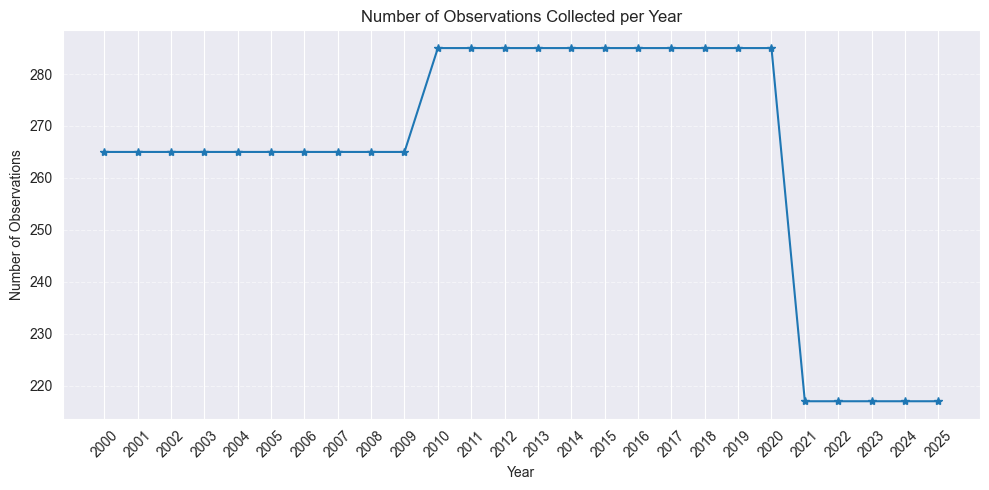

In [196]:
# TODO: Redo the second plot from Phase 2 here.

# Sorts by year, takes counts of data per year
year_counts = df_merged_clean["year"].value_counts().sort_index()

# Create line plot
plt.figure(figsize=(10, 5))
plt.plot(year_counts.index, year_counts.values, marker='*')

plt.title("Number of Observations Collected per Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In the original version, the plot was weaker since each year had a bar chart attached to it, and since this dataset has a lot of years, a bar chart got confusing due to all the bars. I switched the plot type to a line, and now it is much more clear and the line plot also displays the trend of the years and whether data collection was consistent throughout them, which the bar charts did not display.

# Part C: Specific Questions About Your Project

Use your own project dataset to answer the following required questions.


## Part C, Question 1: Comparison with conditioning

Choose one categorical variable and one numerical variable from your project.

Create a plot that answers this question:

**Which groups differ the most on this numerical variable?**

Requirements:
- You must use grouping or conditioning.
- You must explain how the data was aggregated, if aggregation was used.

After the plot, write 4 to 6 full sentences answering:
1. What are the groups?
2. What numerical variable are you comparing?
3. What method did you use to summarize the data?
4. Which groups stand out most?
5. Is the comparison easy to interpret?


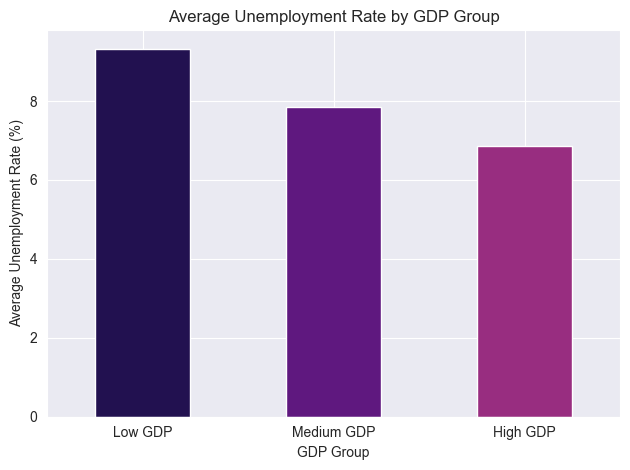

In [197]:
# TODO: Create the comparison plot for your project dataset.
avg_unemployment_gdp = df_merged_clean.groupby("gdp_group", observed=False)["unemployment_rate"].mean().sort_values(ascending=False)

avg_unemployment_gdp.plot(kind="bar",color=sns.color_palette("magma"))

plt.title("Average Unemployment Rate by GDP Group")
plt.xlabel("GDP Group")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The groups within this plot are Low GDP, Medium GDP, and High GDP, and these categories are defined by splitting the countries in this dataset into three even groups based on their GDPs. The average unemployment rate percentage data of these countries by group is the numerical value that we are comparing. I utilized averaging (taking the mean) to summarize the data so that we could easily compare value by GDP group rather than by individual country or distribution of unemployment rate by GDP group. The High and Low GDP groups stand out the most as they are opposite ends of the spectrum, and there is a noticeable difference in average unemployment rate percentage between them. It is noticeable that as the GDP group increases, the unemployment rate percentage clearly goes down. The comparison is very easy to interpret using a bar chart, as it is very clear and straightforward with minimal detail and simple statistics.

## Part C, Question 2: Distribution and transformation

Choose one important numerical variable from your project.

Create:
- one original distribution plot
- one transformed version of that plot

After the plots, write 4 to 6 full sentences answering:
1. What does the original distribution look like?
2. Does the variable appear skewed or spread out?
3. Why did you choose this transformation?
4. What does the transformed version reveal more clearly?
5. Which version would you show to a reader, and why?


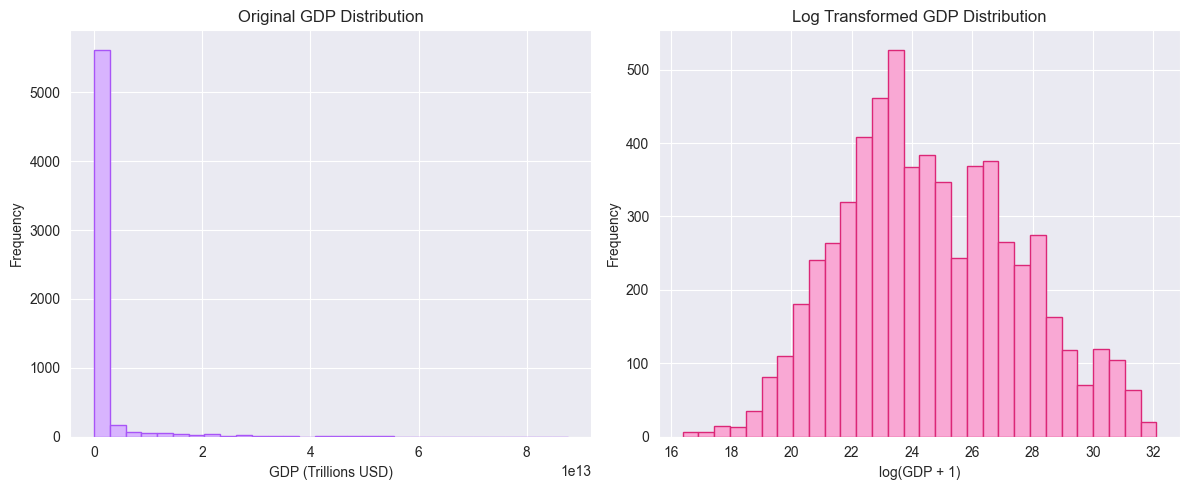

In [198]:
plt.figure(figsize=(12,5))

# Original histogram.
plt.subplot(1,2,1)
plt.hist(
    df_merged_clean["gdp_usd"].dropna(),
    bins=30,
    color="#d8b4fe",
    edgecolor="#a855f7"
)
plt.title("Original GDP Distribution")
plt.xlabel("GDP (Trillions USD)")
plt.ylabel("Frequency")

# Log transformed histogram.
plt.subplot(1,2,2)
plt.hist(
    np.log1p(df_merged_clean["gdp_usd"].dropna()),
    bins=30,
    color="#f9a8d4",
    edgecolor="#db2777"
)
plt.title("Log Transformed GDP Distribution")
plt.xlabel("log(GDP + 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The original distribution is largely unimodal and skewed much to the right, with many countries crowded along the lower GDP values and very little at the higher end. The variable appears to be extremely skewed to the right. I chose the log transformation since the log transformation reduces the effect of the higher outliers, and displays the variability amongst the smaller GDP values. The transformed version reveals the variation and distribution of GDPs much more clearly, and it is much easier to notice the GDP trend since most countries do not have extremely high GDPs. Therefore, I would definitely show the log transformed GDP distribution graph to a reader, as the first graph makes it difficult to see the variation amongst most countries and therefore most of the data is incomprehensible, while in the second graph the variation and distribution is much more clear and obvious.

## Part C, Question 3: Scale and misleading design

Create one plot from your project that could be misleading if scaled badly.

Then:
- create the misleading version
- create the corrected version

After the plots, write 4 to 6 full sentences answering:
1. What scaling choice made the first plot misleading?
2. Why is that misleading?
3. How did you fix it?
4. What is the main lesson from this example?


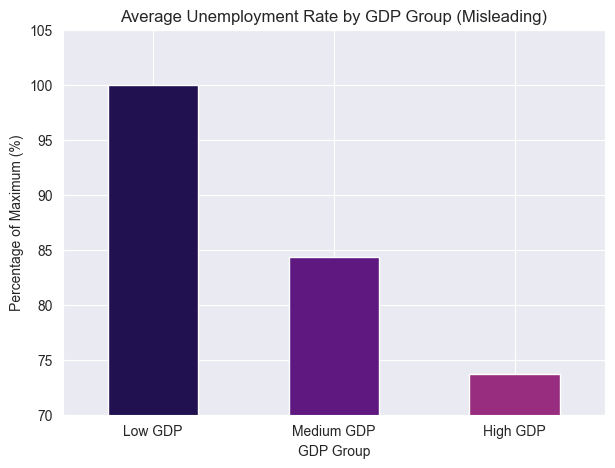

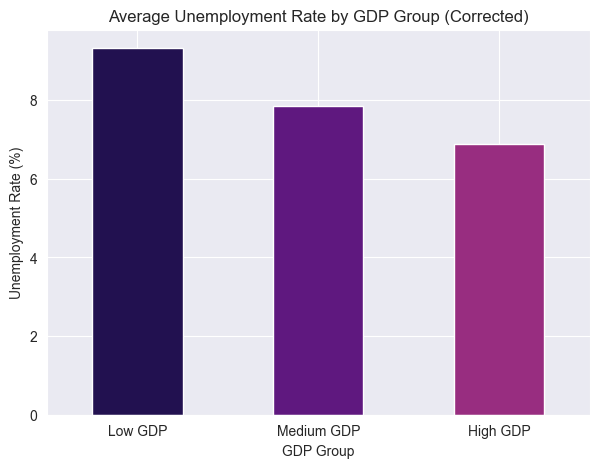

In [199]:
# TODO: Create a misleading project plot and then fix it.

# Takes mean of unemployment rate by each GDP group.
# Misleads by taking maximum percentage values of average unemployment rates, which exaggerates them.
avg_unemployment_by_gdp = df_merged_clean.groupby('gdp_group', observed = False)['unemployment_rate'].mean()
misleading = avg_unemployment_by_gdp / avg_unemployment_by_gdp.max() * 100

plt.figure(figsize=(7,5))
misleading.plot(kind='bar', color=sns.color_palette("magma"))
plt.title("Average Unemployment Rate by GDP Group (Misleading)")
plt.ylabel("Percentage of Maximum (%)")
plt.xlabel("GDP Group")

# Misleads again by truncating the y limits, exaggeration.
plt.ylim(70, 105)
plt.xticks(rotation=0)
plt.show()

# Non-misleading corrected version
plt.figure(figsize=(7,5))
avg_unemployment_by_gdp.plot(kind='bar', color=sns.color_palette("magma"))
plt.title("Average Unemployment Rate by GDP Group (Corrected)")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("GDP Group")
plt.xticks(rotation=0)
plt.show()

The scaling choice on the first plot made it misleading, as it seemingly displays a much more intense difference in percentages of unemployment rate in relation to GDP group. This is caused by the y-axis being truncated to include only the top portion of each graph, as well as the maximum percentage values being taken, both done to exaggerate the difference between the GDP groups in the visual. This is misleading as in the corrected graph, the differences between the bars are much smaller, and more representative of the data than how it is displayed in the first misleading graph. I fixed the graph by returning the y-axis back to start from 0, and by keeping the original unemployment rate percentage values. The main lesson from this example is the importance of displaying data properly and visualizing it in a way that is easily understandable and does not cause confusion or misunderstanding to those viewing it.

## Part C, Question 4: Communication and context

Take one of your project plots and improve it for communication.

Your improved version must include:
- a meaningful title
- clear axis labels
- readable categories or ticks
- a short caption of 2 to 4 sentences

Your caption must explain:
- what the plot shows
- one important takeaway
- why the plot is useful for your project question


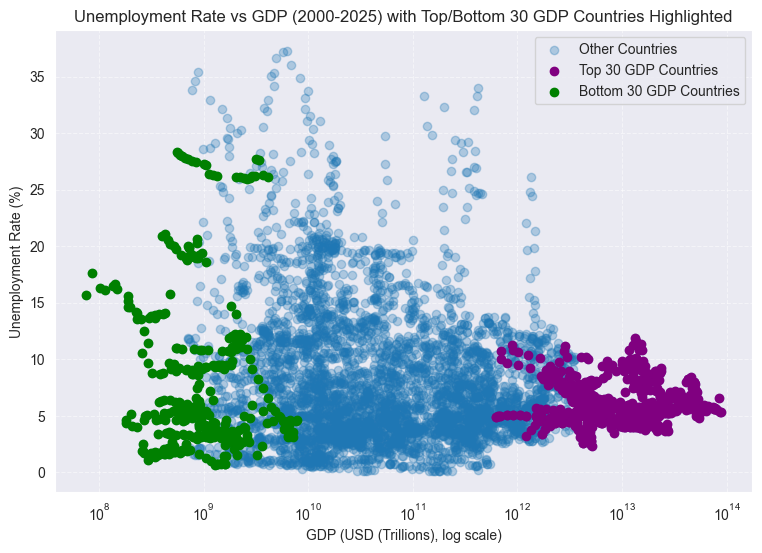

In [200]:
# TODO: Create a polished version of one of your project plots.
plt.figure(figsize=(9,6))
plt.scatter(df_merged_clean['gdp_usd'], df_merged_clean['unemployment_rate'], alpha=0.3, label='Other Countries')

# Top 30 GDP countries get highlighted
top_gdp_countries = df_merged_clean.groupby('country_name')['gdp_usd'].max().nlargest(30)
top_data = df_merged_clean[df_merged_clean['country_name'].isin(top_gdp_countries.index)]
plt.scatter(top_data['gdp_usd'], top_data['unemployment_rate'], color='purple', label='Top 30 GDP Countries')

# Bottom 30 GDP countries get highlighted
bottom_gdp_countries = df_merged_clean.groupby('country_name')['gdp_usd'].min().nsmallest(30)
bottom_data = df_merged_clean[df_merged_clean['country_name'].isin(bottom_gdp_countries.index)]
plt.scatter(bottom_data['gdp_usd'], bottom_data['unemployment_rate'], color='green', label='Bottom 30 GDP Countries')

plt.xscale('log')
plt.title("Unemployment Rate vs GDP (2000-2025) with Top/Bottom 30 GDP Countries Highlighted")
plt.xlabel("GDP (USD (Trillions), log scale)")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

This plot displays a scatter plot of GDP and unemployment rate, consisting of the data from the dataset to display trends within the data and the relationship between these two variables. In this visual, I highlighted the top and bottom 30 countries to display the different trends in unemployment rate between them. It is noticeable that the trends are quite different with unemployment rates being much more spread out for lower GDP countries than for higher GDP countries, in which the unemployment rates are usually relatively lower. This plot directly correlates with our project question: How do unemployment rates vary across countries in relation to GDP growth from 2010 to 2025?, as it shows the relationship that GDP and unemployment rate have, allowing us to notice trends with countries across different income levels. Through this, we can see the difference between countries at opposing ends of the GDP spectrum.


# Part D: Reflection

Write one full paragraph answering the following:

- What did you learn about visualization from this assignment?
- What mistake were you making before?
- How did scale, transformation, or conditioning change your interpretation?
- What did you learn from intentionally making a misleading plot?


From this assignment, I understood the role that proper visualization plays in not only displaying statistics accurately, but also ethically. It is very important to display data in an easily digestible, as well as readable manner so that those viewing it can simply understand it with minimal room to misinterpret the data. Intentionally making a misleading plot taught me that it is very simple to mislead others through data visualization, and that proper care should be taken while creating data visualizations since the representation of data can be consequential in many cases. Before, I was making quite a few mistakes with the visualization of my data, and it caused difficulty to not only interpret the data, but the data being difficult to interpret may have caused unintentional misunderstanding as well. I was layering graphs and utilizing improper plot types for certain data charts and this caused my visualizations to be not as effective as they possibly could have been. After transforming and reformatting much of my data, as well as scaling/conditioning it, the data was much easier to interpret, and I could conclude from the charts much easier. Overall, this was a useful assignment that allowed me to note the importance of proper data visualization.

## Final check before submission

Before you submit, make sure:
- every required section is present
- every plot has interpretation in full sentences
- Part A includes discussion of scale, transformation, and grouping
- you included the intentionally misleading plot and corrected version
- your project plots are improved, not just copied
- your notebook exports cleanly to PDF
